# Purpose

Calculate h_a for different combinations of Avobenzone and NPS absorber concentrations and various source spectra, including:

- 365 nm 
    - with 370 nm short pass filter
- 385 nm
    - full spectrum
    - 400 nm short pass filter
    - 390-400 nm band pass filter
- 405 nm
    - full spectrum
    - short pass filter
    - band pass filter
    - Also try Sudan I with Avobenzone?
    
Use the Asahi calculated transmission data from 2021 for the bandpass filter.

Develop source spectrum manipulation tools to do the following:

- Shift spectrum left or right while filling in data on shifted end of spectrum so full wavelength range is available.
- Define filter transmission properties as a spectrum.
- Apply a filter to another spectrum (multiply two spectra--the filter transmission and the source spectrum).
    - Short pass
    - Band pass
- Define some filters
    - 370 nm short pass
    - Asahi calculated band pass
        - 10 nm band pass (380 nm with 10 nm width at 1% transmission bandwidth)
        - 15 nm band pass (360 nm with 15 nm width at 1% transmission bandwidth)
    - Constructed band pass

# Imports

In [1]:
import copy
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

from scipy.interpolate import interp1d
import scipy
print(scipy.__version__)

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams, find_index_of_nearest, find_index_of_max, shift, shift_peak_wavelength
from spectra.normalizeddose import NormalizedDose
from spectra.sourcespectrum import SourceSpectrum

1.8.1


In [2]:
help(data)

Help on package spectra.data in spectra:

NAME
    spectra.data

PACKAGE CONTENTS
    absorbers (package)
    sources (package)

DATA
    absorbers = {'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectr...
    absorbers_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p...
    material_abbreviations = {'Avobenzone': 'Avo', 'BLS99-2': 'B99', 'BME'...
    monomers = {'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_prin.....
    monomers_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p....
    photoinitiators = {'irgacure819_in_PEGDA_2017-04-13': <spectra.absorbe...
    photoinitiators_directory = PosixPath('/Users/nordin/Documents/Project...
    sources = {'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectr...
    sources_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p.....

FILE
    /Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/__init__.py




In [3]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f8843dc0>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f8843fd0>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f8843f70>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f88601c0>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f8860220>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f8860280>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f88602e0>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f8860340>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f84f88603a0>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.S

In [4]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843a30>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843b50>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843a60>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843ac0>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843c10>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843a90>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843c70>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843b80>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843cd0>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7f84f8843d00>,
 'sudanI_in_PEGDA_2017-04

# Common variables

In [5]:
wavelengths = np.linspace(*ArrayParams(300, 480, 361))

z_array_params = ArrayParams(0, 100, 201)

# wavelength_array_params=ArrayParams(300, 440, 281)

save_plot_figures = False

# Resin precursors

In [6]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
# avobenzone = ResinConstituentAbsorber(
#     data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
#     2.0
# )

nps_2p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)

irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

# resin = Resin(monomers=pegda, absorbers=[avobenzone,nps], photoinitiators=irgacure819)
resin_nps_2p0 = Resin(monomers=pegda, absorbers=nps_2p0, photoinitiators=irgacure819)
# resin_avo = Resin(monomers=pegda, absorbers=avobenzone)


# 405 nm source

In [7]:
source_405nm = data.sources['Asiga_405nm_100um_fiber-2016-12-14']


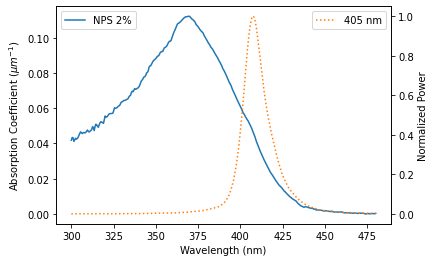

In [8]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C1', ls=':', label='405 nm')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');

if save_plot_figures: plt.savefig('405nm_NPS.png')


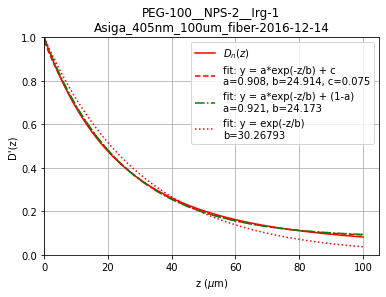

In [9]:
irradiance_405 = Irradiance(source=source_405nm, resin=resin_nps_2p0, wavelength_array_params=ArrayParams(300, 470, 601))
norm_dose_405 = NormalizedDose(irradiance=irradiance_405, z_array_params=z_array_params)

norm_dose_405.plot(title=(norm_dose_405.irradiance.resin.name + "\n" + norm_dose_405.irradiance.source.name));

if save_plot_figures: plt.savefig('NormDose_365nm_source.png')


# Filters

- Start with filter data, list of wavelength, transmission values.
- Construct a 1D interpolation function.
- Build in a shift capability.

In [10]:
asahi_measured_data = np.genfromtxt('370nm shortpass filter_original.csv', delimiter=',', skip_header=2)

# Convert from percent to fractional transmission
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/100.

# Create shifted data
asahi_shift_nm = 40
asahi_shifted = np.copy(asahi_measured_data)
asahi_shifted[:, 1] = shift(asahi_measured_data[:, 1], asahi_shift_nm, asahi_measured_data[0, 1])

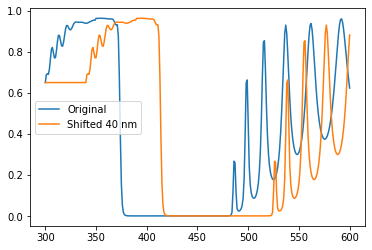

In [11]:
fig, ax = plt.subplots()
ax.plot(asahi_measured_data[:, 0], asahi_measured_data[:, 1], label="Original")
ax.plot(asahi_shifted[:, 0], asahi_shifted[:, 1], label=f"Shifted {asahi_shift_nm} nm")
ax.legend();

In [12]:
def num_indices_to_shift(shift_nm, wavelengths_nm):
    # Assume wavelengths_nm is evenly sampled
    delta_lambda = wavelengths_nm[1] - wavelengths_nm[0]

    return int(np.rint(shift_nm / delta_lambda))

def shift_spectrum(shift_nm, wavelengths_nm, values, fill_value=None):
    num_shift = num_indices_to_shift(shift_nm, wavelengths)
    # print(num_shift)
    if fill_value is None:
        fill_value = values[0] if num_shift > 0 else values[-1]
    # print(fill_value)
    return shift(values, num_shift, fill_value=fill_value)


In [13]:
asahi_shortpass = interp1d(asahi_measured_data[:, 0], asahi_measured_data[:, 1], bounds_error=False, fill_value=1.0)

asahi_interpolated = asahi_shortpass(wavelengths)


In [14]:
asahi_interpolated_shifted_m20 = shift_spectrum(-20, wavelengths, asahi_interpolated)
asahi_interpolated_shifted_20 = shift_spectrum(20, wavelengths, asahi_interpolated)
asahi_interpolated_shifted_30 = shift_spectrum(30, wavelengths, asahi_interpolated)
asahi_interpolated_shifted_40 = shift_spectrum(40, wavelengths, asahi_interpolated)

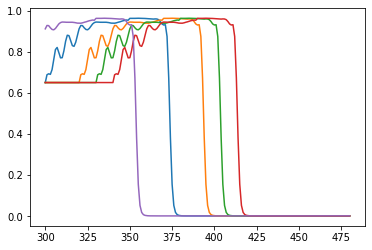

In [15]:

fig, ax = plt.subplots()
ax.plot(wavelengths, asahi_interpolated)
ax.plot(wavelengths, asahi_interpolated_shifted_20)
ax.plot(wavelengths, asahi_interpolated_shifted_30)
ax.plot(wavelengths, asahi_interpolated_shifted_40)
ax.plot(wavelengths, asahi_interpolated_shifted_m20)


In [16]:
source_405nm_shortpass_410nm = source_405nm.calc_power(wavelengths) * asahi_interpolated_shifted_40


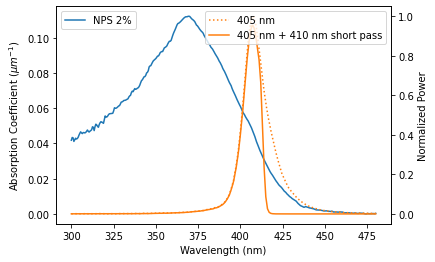

In [17]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C1', ls=':', label='405 nm')
ax2.plot(wavelengths, source_405nm_shortpass_410nm, c='C1', label='405 nm + 410 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');


In [24]:
print(len(source_405nm.wavelength))
delta_lambda = source_405nm.wavelength[1] - source_405nm.wavelength[0]
print(delta_lambda)
delta_lambda = source_405nm.wavelength[501] - source_405nm.wavelength[500]
print(delta_lambda)
      

1044
0.8076045765597542
0.7714332801327828


# How to fix

- Find index of short pass edge (370 nm)
- Find index of short pass edge + `shift_nm`
- Take the difference and shift by that many array positions?

OR:

- Using wavelengths and values create an interpolation function
- Sample interpolation function uniformly to create new wavelengths and values arrays
- Use these arrays to shift the values array by correct number of array positions
- Create new interpolation function for shifted values
- Use new interpolation function to get new `power` array using original `wavelength` array



# Create `FilteredSpectrum` class

In [18]:
class FilteredSpectrum(SourceSpectrum):
    
    def __init__(self, original_source, filter_func, shift_nm=0, name="Needs name"):
        self.name = name
        self.original_source = original_source
        self.wavelength = np.copy(self.original_source.wavelength)
        self.power = np.copy(self.original_source.power)
        self.filter_transmission = filter_func(self.wavelength)
        if shift_nm != 0:
            self.filter_transmission = shift_spectrum(shift_nm, self.wavelength, self.filter_transmission)
        self.power *= self.filter_transmission

shift_spectrum(shift_nm, wavelengths_nm, values

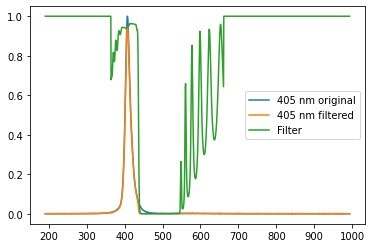

In [22]:
source_405nm_shortpass_410nm = FilteredSpectrum(source_405nm, asahi_shortpass, shift_nm=40, name="410 nm short pass")

fig, ax = plt.subplots()
ax.plot(source_405nm.wavelength, source_405nm.power, label="405 nm original")
ax.plot(source_405nm_shortpass_410nm.wavelength, source_405nm_shortpass_410nm.power, label="405 nm filtered")
ax.plot(source_405nm_shortpass_410nm.wavelength, source_405nm_shortpass_410nm.filter_transmission, label="Filter")
ax.legend();

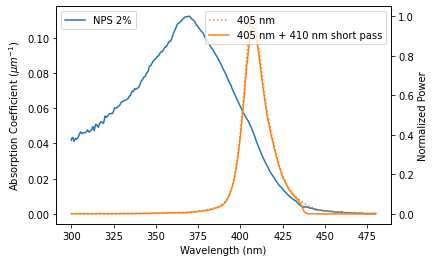

In [20]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C1', ls=':', label='405 nm')
ax2.plot(wavelengths, source_405nm_shortpass_410nm.calc_power(wavelengths), c='C1', label='405 nm + 410 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');
